# Notebook 09 — Prophet: Olympia Station (Recreational)
**Cross-station Prophet comparison: does weather sensitivity pattern hold?**

Notebook 08 found that Prophet + weather dramatically outperforms SARIMAX on Hirsch (351 vs 471 RMSE, 28% improvement). This notebook applies the same Prophet framework to **Olympia** (recreational station, WD/WE ratio 1.16×) to test whether the weather gain is even larger on a recreation-dominated station.

| Part | Content |
|------|---------|
| 1 | Data loading and Olympia-specific preparation |
| 2 | Seasonality mode selection (additive vs multiplicative) |
| 3 | Baseline Prophet (no weather) |
| 4 | Prophet + weather regressors |
| 5 | Weather gain comparison: Hirsch vs Olympia (SARIMAX and Prophet) |
| 6 | Forecast visualisation |
| 7 | Artefact export and summary |

**Hypothesis:** Olympia's recreational demand is more weather-sensitive than Hirsch's commuter demand → Prophet weather gain should be higher than Hirsch's 28%.

**SARIMAX benchmarks (from nb06):** Fourier-only 835 RMSE | Fourier+weather 760 RMSE (9.0% gain).

In [1]:
import sys, warnings, logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import holidays
from prophet import Prophet

logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)
warnings.filterwarnings('ignore')

sys.path.insert(0, '../src')

plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 11, 'axes.labelsize': 12,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.spines.top': False, 'axes.spines.right': False,
    'legend.frameon': False,
})
sns.set_theme(style='whitegrid')

FIGURES = Path('../results/figures')
TABLES  = Path('../results/tables')
PREDS   = Path('../results/predictions')
for p in [FIGURES, TABLES]:
    p.mkdir(parents=True, exist_ok=True)

WEATHER_COLS = ['max_temp', 'sunshine_hours', 'precipitation']

TRAIN_START = '2013-01-01'
TRAIN_END   = '2022-12-31'
VAL_START   = '2023-01-01'
VAL_END     = '2023-12-31'
TEST_START  = '2024-01-01'
TEST_END    = '2026-04-30'

# ── Load SARIMAX benchmarks from upstream CSVs (no hardcoding) ───────────
_cross_ref   = pd.read_csv(TABLES / 'hirsch_olympia_comparison.csv')
_olympia_row = _cross_ref[_cross_ref['Station'] == 'Olympia'].iloc[0]
_hirsch_row  = _cross_ref[_cross_ref['Station'] == 'Hirsch'].iloc[0]

SARIMAX_FOURIER_RMSE = float(_olympia_row['Fourier-only RMSE'])
SARIMAX_FOURIER_MAE  = float(_olympia_row['Fourier-only MAE'])
SARIMAX_FULL_RMSE    = float(_olympia_row['Full model RMSE'])
SARIMAX_FULL_MAE     = float(_olympia_row['Full model MAE'])
SARIMAX_WEATHER_GAIN = float(_olympia_row['Weather gain (%)'])

# Hirsch SARIMAX values for cross-station comparison in Part 5
HIRSCH_SARIMAX_FOURIER_RMSE = float(_hirsch_row['Fourier-only RMSE'])
HIRSCH_SARIMAX_FULL_RMSE    = float(_hirsch_row['Full model RMSE'])
HIRSCH_SARIMAX_WEATHER_GAIN = float(_hirsch_row['Weather gain (%)'])

# Hirsch Prophet benchmarks (from nb08 output)
_h_prophet_df = pd.read_csv(TABLES / 'hirsch_prophet_performance.csv')
_h_base = _h_prophet_df[_h_prophet_df['Model'].str.startswith('Prophet baseline')].iloc[0]
_h_wx   = _h_prophet_df[_h_prophet_df['Model'].str.startswith('Prophet + weather')].iloc[0]
HIRSCH_PROPHET_BASE_RMSE = float(_h_base['Test 7d RMSE'])
HIRSCH_PROPHET_FULL_RMSE = float(_h_wx['Test 7d RMSE'])
HIRSCH_PROPHET_GAIN      = round((HIRSCH_PROPHET_BASE_RMSE - HIRSCH_PROPHET_FULL_RMSE) /
                                  HIRSCH_PROPHET_BASE_RMSE * 100, 1)

# ── notebook prefix: all figures saved as nb09_<name>.png ────────────────

# Bavaria public holidays for Prophet (2013-2026)
_by_hols = holidays.Germany(state='BY', years=range(2013, 2027))
holiday_df = pd.DataFrame([
    {'ds': pd.Timestamp(d), 'holiday': name, 'lower_window': 0, 'upper_window': 0}
    for d, name in _by_hols.items()
])
NB = 'nb09'

def savefig(name):
    full_name = f'{NB}_{name}'
    plt.savefig(FIGURES / f'{full_name}.png', bbox_inches='tight', dpi=300)
    plt.show()
    print(f'  saved → results/figures/{full_name}.png')

print('Setup complete.')
print(f'Olympia SARIMAX: Fourier RMSE={SARIMAX_FOURIER_RMSE}, MAE={SARIMAX_FOURIER_MAE}, Full RMSE={SARIMAX_FULL_RMSE}, gain={SARIMAX_WEATHER_GAIN}%')
print(f'Hirsch  Prophet: base RMSE={HIRSCH_PROPHET_BASE_RMSE}, full RMSE={HIRSCH_PROPHET_FULL_RMSE}, gain={HIRSCH_PROPHET_GAIN}%')

/Users/sousadaniela/time-series-rad/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


Setup complete.
Olympia SARIMAX: Fourier RMSE=835.0, MAE=705.2, Full RMSE=759.8, gain=9.0%
Hirsch  Prophet: base RMSE=472.8, full RMSE=316.5, gain=33.1%


## Part 1 — Data Loading and Olympia-Specific Preparation

Olympia has two training-period gaps requiring interpolation:
- **2 days** (Oct 2016) — trivial, linear fill
- **78 days** (Jun–Sep 2022) — summer gap, time-based interpolation

No gaps in validation or test periods.

In [2]:
df_raw = pd.read_csv('../data/processed/master_bike_data.csv', parse_dates=['date'])

olympia = (
    df_raw[df_raw['station'] == 'Olympia']
    .set_index('date')
    .sort_index()[['total'] + WEATHER_COLS]
    .interpolate(method='time', limit=None)  # fills both training gaps
    .dropna()
)

# Confirm no residual NAs in training period
train_na = olympia.loc[TRAIN_START:TRAIN_END, 'total'].isna().sum()
print(f'Training NAs after interpolation: {train_na}')

# Convert to Prophet format
df_prophet = olympia.reset_index().rename(columns={'date': 'ds', 'total': 'y'})
df_prophet['precipitation'] = np.log1p(df_prophet['precipitation'])

train_df    = df_prophet[(df_prophet['ds'] >= TRAIN_START) & (df_prophet['ds'] <= TRAIN_END)].copy()
val_df      = df_prophet[(df_prophet['ds'] >= VAL_START) & (df_prophet['ds'] <= VAL_END)].copy()
test_df     = df_prophet[(df_prophet['ds'] >= TEST_START) & (df_prophet['ds'] <= TEST_END)].copy()
trainval_df = pd.concat([train_df, val_df], ignore_index=True)

print(f'Train: {len(train_df):,} days  ({train_df.ds.min().date()} – {train_df.ds.max().date()})')
print(f'Val:   {len(val_df):,} days  ({val_df.ds.min().date()} – {val_df.ds.max().date()})')
print(f'Test:  {len(test_df):,} days  ({test_df.ds.min().date()} – {test_df.ds.max().date()})')
print(f'\nOlympia target range: {olympia["total"].min():.0f} – {olympia["total"].max():.0f} cyclists/day')

hirsch_raw = df_raw[df_raw['station']=='Hirsch']['total']
print(f'Hirsch target range:  {hirsch_raw.min():.0f} – {hirsch_raw.max():.0f} cyclists/day')

Training NAs after interpolation: 0
Train: 3,652 days  (2013-01-01 – 2022-12-31)
Val:   365 days  (2023-01-01 – 2023-12-31)
Test:  851 days  (2024-01-01 – 2026-04-30)

Olympia target range: 0 – 15009 cyclists/day
Hirsch target range:  0 – 3745 cyclists/day


## Part 2 — Seasonality Mode: Additive vs Multiplicative

Hirsch selected **multiplicative** mode. Testing whether Olympia (recreational) agrees — recreational demand may show even stronger multiplicative interaction between season and day-of-week.

In [3]:
def rolling_rmse_mae(y_true, y_pred, horizon=7):
    """Non-overlapping rolling window evaluation — matches all other notebooks."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n = len(y_true)
    rmses, maes = [], []
    for start in range(0, n - horizon + 1, horizon):
        sl = slice(start, start + horizon)
        err = y_true[sl] - y_pred[sl]
        rmses.append(np.sqrt(np.mean(err**2)))
        maes.append(np.mean(np.abs(err)))
    return float(np.mean(rmses)), float(np.mean(maes))


def fit_prophet(train, future_df, mode='multiplicative', use_weather=False,
                changepoint_prior_scale=0.05):
    m = Prophet(
        seasonality_mode=mode,
        holidays=holiday_df,
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        changepoint_prior_scale=changepoint_prior_scale,
    )
    if use_weather:
        for col in WEATHER_COLS:
            m.add_regressor(col)
    m.fit(train)
    forecast = m.predict(future_df)
    return m, forecast['yhat'].values


val_future  = val_df[['ds'] + WEATHER_COLS].copy()
test_future = test_df[['ds'] + WEATHER_COLS].copy()

print('Testing seasonality modes on validation set...')
mode_results = {}
for mode in ['additive', 'multiplicative']:
    _, preds = fit_prophet(train_df, val_future[['ds']], mode=mode, use_weather=False)
    rmse, mae = rolling_rmse_mae(val_df['y'].values, preds)
    mode_results[mode] = {'Val 7d RMSE': round(rmse, 1), 'Val 7d MAE': round(mae, 1)}
    print(f'  {mode:>15s}: Val RMSE={rmse:.1f}, MAE={mae:.1f}')

best_mode = min(mode_results, key=lambda m: mode_results[m]['Val 7d RMSE'])
print(f'\nSelected seasonality mode: {best_mode}')
print(f'(Hirsch selected: multiplicative — match={best_mode=="multiplicative"})')

Testing seasonality modes on validation set...


16:16:14 - cmdstanpy - INFO - Chain [1] start processing


16:16:15 - cmdstanpy - INFO - Chain [1] done processing


         additive: Val RMSE=827.5, MAE=693.5


16:16:15 - cmdstanpy - INFO - Chain [1] start processing


16:16:15 - cmdstanpy - INFO - Chain [1] done processing


   multiplicative: Val RMSE=820.6, MAE=683.5

Selected seasonality mode: multiplicative
(Hirsch selected: multiplicative — match=True)


## Part 3 — Baseline Prophet (No Weather)

SARIMAX Fourier-only benchmark for Olympia is **835 RMSE** — already higher than Hirsch (498) reflecting the noisier recreational demand pattern.

In [4]:
print(f'Fitting baseline Prophet ({best_mode}) — val evaluation...')
_, base_val_preds = fit_prophet(train_df, val_future[['ds']], mode=best_mode, use_weather=False)
base_val_rmse, base_val_mae = rolling_rmse_mae(val_df['y'].values, base_val_preds)

print(f'Fitting baseline Prophet ({best_mode}) — test evaluation (refit on train+val)...')
_, base_test_preds = fit_prophet(trainval_df, test_future[['ds']], mode=best_mode, use_weather=False)
base_test_rmse, base_test_mae = rolling_rmse_mae(test_df['y'].values, base_test_preds)

print(f'\nProphet baseline ({best_mode})')
print(f'  Val  7d RMSE: {base_val_rmse:.1f}  MAE: {base_val_mae:.1f}')
print(f'  Test 7d RMSE: {base_test_rmse:.1f}  MAE: {base_test_mae:.1f}')
print(f'\n  SARIMAX Fourier-only benchmark: RMSE {SARIMAX_FOURIER_RMSE}')
sarimax_base_gap = (base_test_rmse - SARIMAX_FOURIER_RMSE) / SARIMAX_FOURIER_RMSE * 100
print(f'  Prophet vs SARIMAX baseline: {sarimax_base_gap:+.1f}%')

Fitting baseline Prophet (multiplicative) — val evaluation...


16:16:16 - cmdstanpy - INFO - Chain [1] start processing


16:16:16 - cmdstanpy - INFO - Chain [1] done processing


Fitting baseline Prophet (multiplicative) — test evaluation (refit on train+val)...


16:16:16 - cmdstanpy - INFO - Chain [1] start processing


16:16:17 - cmdstanpy - INFO - Chain [1] done processing



Prophet baseline (multiplicative)
  Val  7d RMSE: 820.6  MAE: 683.5
  Test 7d RMSE: 792.6  MAE: 661.5

  SARIMAX Fourier-only benchmark: RMSE 835.0
  Prophet vs SARIMAX baseline: -5.1%


## Part 4 — Prophet + Weather Regressors

The key test: does Prophet amplify Olympia's weather sensitivity more than SARIMAX did?

In [5]:
print(f'Fitting Prophet + weather ({best_mode}) — val evaluation...')
m_wx_val, wx_val_preds = fit_prophet(train_df, val_future, mode=best_mode, use_weather=True)
wx_val_rmse, wx_val_mae = rolling_rmse_mae(val_df['y'].values, wx_val_preds)

print(f'Fitting Prophet + weather ({best_mode}) — test evaluation (refit on train+val)...')
m_wx_test, wx_test_preds = fit_prophet(trainval_df, test_future, mode=best_mode, use_weather=True)
wx_test_rmse, wx_test_mae = rolling_rmse_mae(test_df['y'].values, wx_test_preds)

prophet_weather_gain = (base_test_rmse - wx_test_rmse) / base_test_rmse * 100

print(f'\nProphet + weather ({best_mode})')
print(f'  Val  7d RMSE: {wx_val_rmse:.1f}  MAE: {wx_val_mae:.1f}')
print(f'  Test 7d RMSE: {wx_test_rmse:.1f}  MAE: {wx_test_mae:.1f}')
print(f'  Weather gain (Prophet): {prophet_weather_gain:.1f}%')
print(f'\n  SARIMAX full model benchmark: RMSE {SARIMAX_FULL_RMSE}')
sarimax_full_gap = (wx_test_rmse - SARIMAX_FULL_RMSE) / SARIMAX_FULL_RMSE * 100
print(f'  Prophet+weather vs SARIMAX+weather: {sarimax_full_gap:+.1f}%')

Fitting Prophet + weather (multiplicative) — val evaluation...


16:16:17 - cmdstanpy - INFO - Chain [1] start processing


16:16:18 - cmdstanpy - INFO - Chain [1] done processing


Fitting Prophet + weather (multiplicative) — test evaluation (refit on train+val)...


16:16:18 - cmdstanpy - INFO - Chain [1] start processing


16:16:19 - cmdstanpy - INFO - Chain [1] done processing



Prophet + weather (multiplicative)
  Val  7d RMSE: 669.1  MAE: 520.9
  Test 7d RMSE: 542.3  MAE: 446.5
  Weather gain (Prophet): 31.6%

  SARIMAX full model benchmark: RMSE 759.8
  Prophet+weather vs SARIMAX+weather: -28.6%


## Part 5 — Weather Gain Comparison: Hirsch vs Olympia

Comparing weather gain (% RMSE reduction from adding weather) across stations and model families to test the recreational weather-sensitivity hypothesis.

In [6]:
# Build comparison table
# Hirsch SARIMAX values loaded from hirsch_olympia_comparison.csv in setup cell
gain_data = [
    {'Station': 'Hirsch (commuter)',     'Model': 'SARIMAX',
     'Base RMSE': HIRSCH_SARIMAX_FOURIER_RMSE, 'Full RMSE': HIRSCH_SARIMAX_FULL_RMSE,
     'Weather gain (%)': HIRSCH_SARIMAX_WEATHER_GAIN},
    {'Station': 'Hirsch (commuter)',     'Model': 'Prophet',
     'Base RMSE': HIRSCH_PROPHET_BASE_RMSE, 'Full RMSE': HIRSCH_PROPHET_FULL_RMSE,
     'Weather gain (%)': HIRSCH_PROPHET_GAIN},
    {'Station': 'Olympia (recreational)', 'Model': 'SARIMAX',
     'Base RMSE': SARIMAX_FOURIER_RMSE, 'Full RMSE': SARIMAX_FULL_RMSE,
     'Weather gain (%)': SARIMAX_WEATHER_GAIN},
    {'Station': 'Olympia (recreational)', 'Model': 'Prophet',
     'Base RMSE': round(base_test_rmse, 1), 'Full RMSE': round(wx_test_rmse, 1),
     'Weather gain (%)': round(prophet_weather_gain, 1)},
]
gain_df = pd.DataFrame(gain_data)
print('Weather gain comparison:')
print(gain_df.to_string(index=False))

# Key question: is Olympia Prophet gain > Hirsch Prophet gain?
print(f'\nHypothesis check:')
print(f'  Hirsch  Prophet weather gain: {HIRSCH_PROPHET_GAIN:.1f}%')
print(f'  Olympia Prophet weather gain: {prophet_weather_gain:.1f}%')
if prophet_weather_gain > HIRSCH_PROPHET_GAIN:
    print(f'  ✓ Hypothesis CONFIRMED: Olympia gain ({prophet_weather_gain:.1f}%) > Hirsch gain ({HIRSCH_PROPHET_GAIN:.1f}%)')
else:
    print(f'  ✗ Hypothesis NOT confirmed: Olympia gain ({prophet_weather_gain:.1f}%) ≤ Hirsch gain ({HIRSCH_PROPHET_GAIN:.1f}%)')

Weather gain comparison:
               Station   Model  Base RMSE  Full RMSE  Weather gain (%)
     Hirsch (commuter) SARIMAX      497.8      471.0               5.4
     Hirsch (commuter) Prophet      472.8      316.5              33.1
Olympia (recreational) SARIMAX      835.0      759.8               9.0
Olympia (recreational) Prophet      792.6      542.3              31.6

Hypothesis check:
  Hirsch  Prophet weather gain: 33.1%
  Olympia Prophet weather gain: 31.6%
  ✗ Hypothesis NOT confirmed: Olympia gain (31.6%) ≤ Hirsch gain (33.1%)


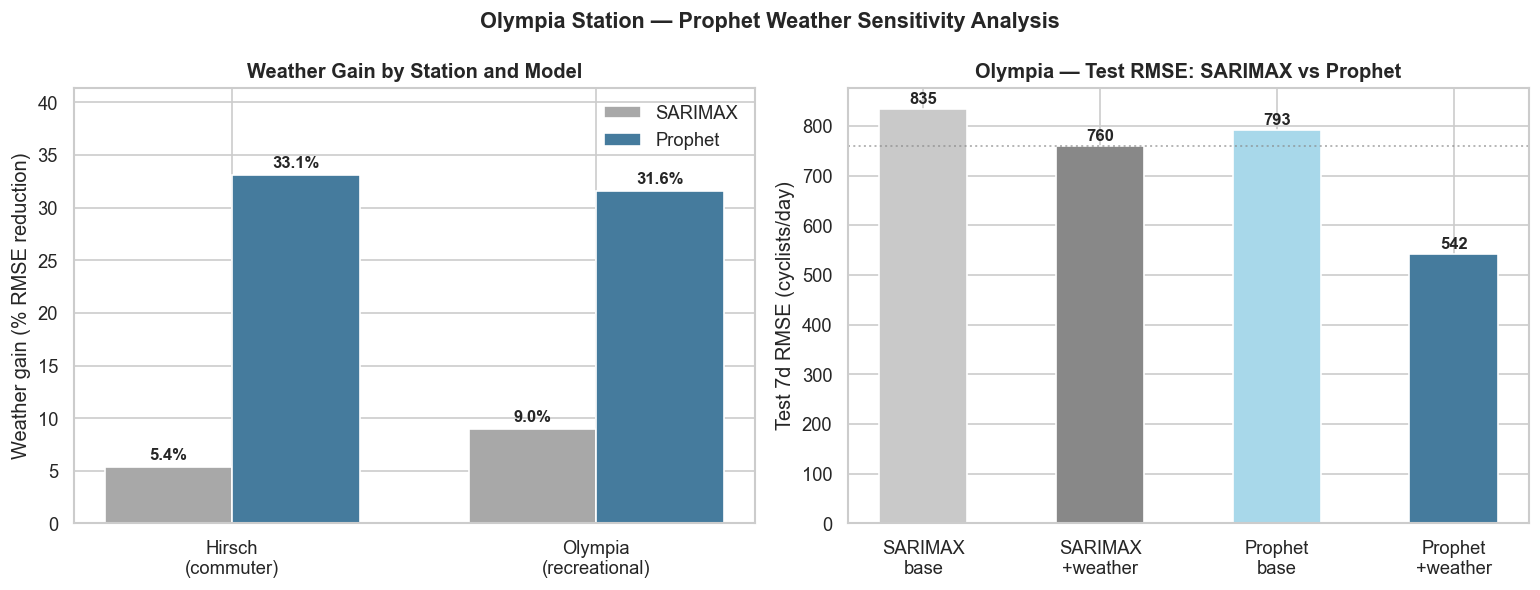

  saved → results/figures/nb09_fig_01_olympia_prophet_weather_gain.png


In [7]:
# Weather gain comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: weather gain % by station and model
ax = axes[0]
stations = ['Hirsch\n(commuter)', 'Olympia\n(recreational)']
sarimax_gains = [HIRSCH_SARIMAX_WEATHER_GAIN, SARIMAX_WEATHER_GAIN]
prophet_gains = [HIRSCH_PROPHET_GAIN, prophet_weather_gain]
x = np.arange(len(stations))
w = 0.35
bars1 = ax.bar(x - w/2, sarimax_gains, w, label='SARIMAX', color='#a8a8a8', edgecolor='white')
bars2 = ax.bar(x + w/2, prophet_gains, w, label='Prophet', color='#457b9d', edgecolor='white')
for bar, val in zip(list(bars1)+list(bars2), sarimax_gains+prophet_gains):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(stations)
ax.set_ylabel('Weather gain (% RMSE reduction)')
ax.set_title('Weather Gain by Station and Model')
ax.legend()
ax.set_ylim(0, max(prophet_gains) * 1.25)

# Right: absolute test RMSE comparison
ax = axes[1]
labels  = ['SARIMAX\nbase', 'SARIMAX\n+weather', 'Prophet\nbase', 'Prophet\n+weather']
rmses   = [SARIMAX_FOURIER_RMSE, SARIMAX_FULL_RMSE, base_test_rmse, wx_test_rmse]
colors  = ['#c9c9c9', '#888888', '#a8d8ea', '#457b9d']
bars = ax.bar(labels, rmses, color=colors, width=0.5, edgecolor='white')
for bar, val in zip(bars, rmses):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
            f'{val:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Test 7d RMSE (cyclists/day)')
ax.set_title('Olympia — Test RMSE: SARIMAX vs Prophet')
ax.axhline(SARIMAX_FULL_RMSE, color='#888888', ls=':', lw=1.2, alpha=0.6)

fig.suptitle('Olympia Station — Prophet Weather Sensitivity Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
savefig('fig_01_olympia_prophet_weather_gain')

## Part 6 — Forecast Visualisation

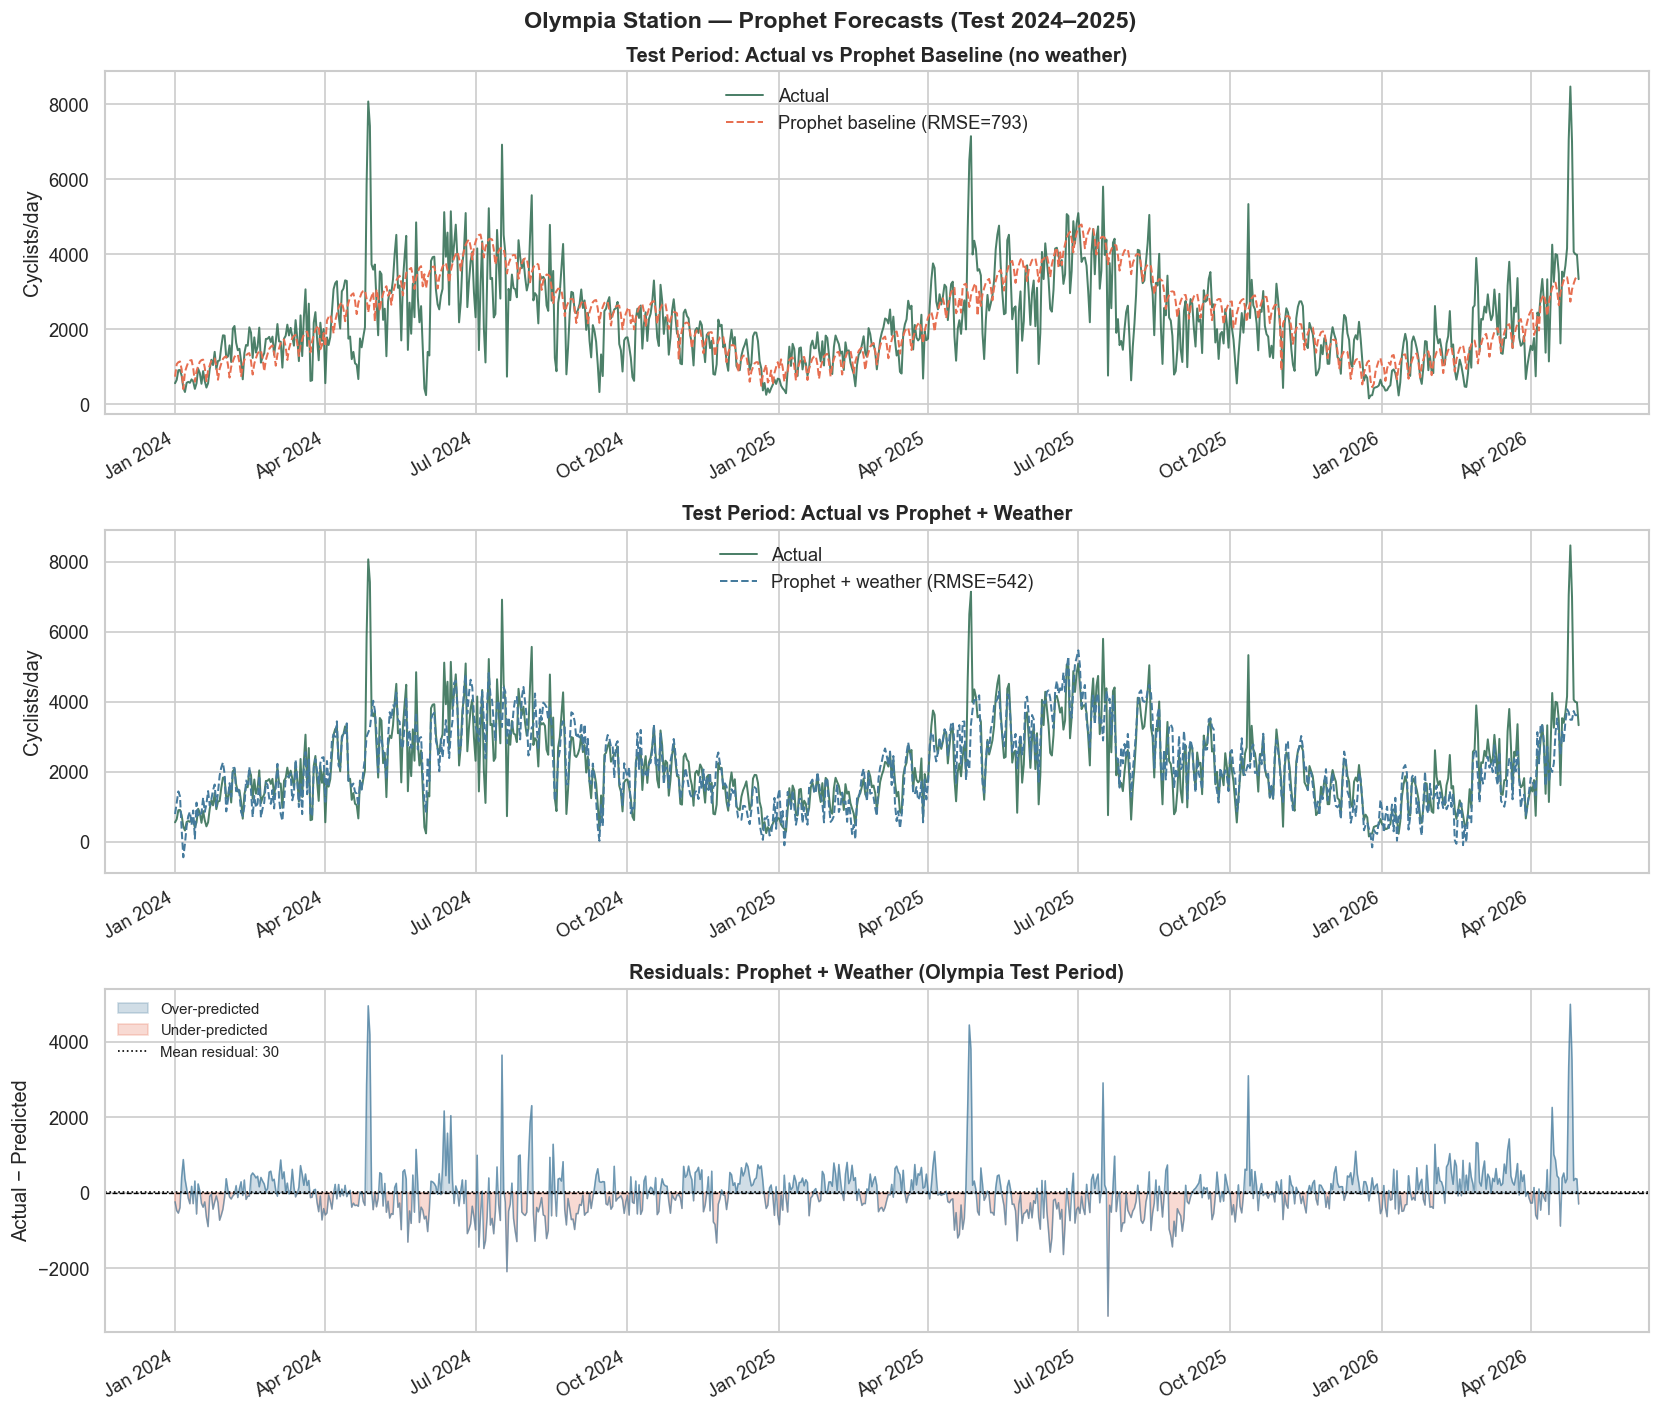

  saved → results/figures/nb09_fig_02_olympia_prophet_predictions.png


In [8]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)
test_dates  = test_df['ds'].values
test_actual = test_df['y'].values

# Panel 1: Baseline Prophet
ax = axes[0]
ax.plot(test_dates, test_actual, color='#2d6a4f', lw=1.2, label='Actual', alpha=0.85)
ax.plot(test_dates, base_test_preds, color='#e76f51', lw=1.2, ls='--',
        label=f'Prophet baseline (RMSE={base_test_rmse:.0f})')
ax.set_title('Test Period: Actual vs Prophet Baseline (no weather)')
ax.set_ylabel('Cyclists/day')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

# Panel 2: Prophet + weather
ax = axes[1]
ax.plot(test_dates, test_actual, color='#2d6a4f', lw=1.2, label='Actual', alpha=0.85)
ax.plot(test_dates, wx_test_preds, color='#457b9d', lw=1.2, ls='--',
        label=f'Prophet + weather (RMSE={wx_test_rmse:.0f})')
ax.set_title('Test Period: Actual vs Prophet + Weather')
ax.set_ylabel('Cyclists/day')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

# Panel 3: Residuals (Prophet+weather)
ax = axes[2]
resid = test_actual - wx_test_preds
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.plot(test_dates, resid, color='#457b9d', lw=0.9, alpha=0.7)
ax.fill_between(test_dates, resid, 0,
                where=(resid > 0), color='#457b9d', alpha=0.25, label='Over-predicted')
ax.fill_between(test_dates, resid, 0,
                where=(resid < 0), color='#e76f51', alpha=0.25, label='Under-predicted')
mean_resid = float(np.mean(resid))
ax.axhline(mean_resid, color='black', lw=1, ls=':', label=f'Mean residual: {mean_resid:.0f}')
ax.set_title('Residuals: Prophet + Weather (Olympia Test Period)')
ax.set_ylabel('Actual − Predicted')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.suptitle('Olympia Station — Prophet Forecasts (Test 2024–2025)', fontsize=14, fontweight='bold')
plt.tight_layout()
savefig('fig_02_olympia_prophet_predictions')

## Part 7 — Artefact Export and Summary

In [9]:
# Performance table
results = [
    {
        'Model': 'Prophet baseline (no weather)',
        'Val 7d RMSE': round(base_val_rmse, 1),
        'Test 7d RMSE': round(base_test_rmse, 1),
        'Val 7d MAE': round(base_val_mae, 1),
        'Test 7d MAE': round(base_test_mae, 1),
    },
    {
        'Model': f'Prophet + weather ({best_mode})',
        'Val 7d RMSE': round(wx_val_rmse, 1),
        'Test 7d RMSE': round(wx_test_rmse, 1),
        'Val 7d MAE': round(wx_val_mae, 1),
        'Test 7d MAE': round(wx_test_mae, 1),
    },
    {
        'Model': 'SARIMAX + Fourier K=4 (benchmark)',
        'Val 7d RMSE': None, 'Test 7d RMSE': SARIMAX_FOURIER_RMSE,
        'Val 7d MAE': None,  'Test 7d MAE': SARIMAX_FOURIER_MAE,
    },
    {
        'Model': 'SARIMAX + Fourier + weather (benchmark)',
        'Val 7d RMSE': None, 'Test 7d RMSE': SARIMAX_FULL_RMSE,
        'Val 7d MAE': None,  'Test 7d MAE': SARIMAX_FULL_MAE,
    },
]
perf_df = pd.DataFrame(results)
perf_df.to_csv(TABLES / 'olympia_prophet_performance.csv', index=False)
print('Saved: olympia_prophet_performance.csv')

gain_df.to_csv(TABLES / 'prophet_weather_gain_comparison.csv', index=False)
print('Saved: prophet_weather_gain_comparison.csv')

print('\n' + '='*60)
print('OLYMPIA PROPHET RESULTS SUMMARY')
print('='*60)
print(f'Seasonality mode selected : {best_mode}')
print(f'\nProphet baseline          : Test RMSE = {base_test_rmse:.1f}, MAE = {base_test_mae:.1f}')
print(f'Prophet + weather         : Test RMSE = {wx_test_rmse:.1f}, MAE = {wx_test_mae:.1f}')
print(f'Weather gain (Prophet)    : {prophet_weather_gain:.1f}%')
print()
print(f'SARIMAX Fourier-only      : Test RMSE = {SARIMAX_FOURIER_RMSE}')
print(f'SARIMAX Full model        : Test RMSE = {SARIMAX_FULL_RMSE}')
print(f'Weather gain (SARIMAX)    : {SARIMAX_WEATHER_GAIN}%')
print()
gap = wx_test_rmse - SARIMAX_FULL_RMSE
print(f'Prophet+weather vs SARIMAX+weather : {gap:+.1f} RMSE ({gap/SARIMAX_FULL_RMSE*100:+.1f}%)')
print()
print(f'Cross-station Prophet weather gain:')
print(f'  Hirsch  (commuter)    : {HIRSCH_PROPHET_GAIN:.1f}%')
print(f'  Olympia (recreational): {prophet_weather_gain:.1f}%')
print()
print(f'Figures saved: nb09_fig_01_olympia_prophet_weather_gain, nb09_fig_02_olympia_prophet_predictions')

Saved: olympia_prophet_performance.csv
Saved: prophet_weather_gain_comparison.csv

OLYMPIA PROPHET RESULTS SUMMARY
Seasonality mode selected : multiplicative

Prophet baseline          : Test RMSE = 792.6, MAE = 661.5
Prophet + weather         : Test RMSE = 542.3, MAE = 446.5
Weather gain (Prophet)    : 31.6%

SARIMAX Fourier-only      : Test RMSE = 835.0
SARIMAX Full model        : Test RMSE = 759.8
Weather gain (SARIMAX)    : 9.0%

Prophet+weather vs SARIMAX+weather : -217.5 RMSE (-28.6%)

Cross-station Prophet weather gain:
  Hirsch  (commuter)    : 33.1%
  Olympia (recreational): 31.6%

Figures saved: nb09_fig_01_olympia_prophet_weather_gain, nb09_fig_02_olympia_prophet_predictions
